# Advanced LFADS Reference: Inferring Inputs to an Integrator RNN

| Tutorial status | Details |
|---|---|
| **Course role** | Advanced/reference JAX LFADS implementation with inferred time-varying inputs |
| **Expected runtime** | Approximately 15-40 minutes, depending on backend |
| **Hardware** | GPU recommended; CPU execution is supported but slower |
| **External data** | Synthetic integrator data generated locally |
| **Validation** | Dependency-heavy reference workflow; not the primary live seminar notebook |


Use `06_lfads.ipynb` for the main transparent PyTorch lesson. This notebook preserves the fuller JAX architecture as an advanced reference.

The goal of this tutorial is to learn about LFADS by running the algorithm on a simple data generator, a vanilla recurrent neural network (RNN) that was [trained to integrate a white noise input](https://github.com/google-research/computation-thru-dynamics/blob/master/notebooks/Integrator%20RNN%20Tutorial.ipynb).  Running LFADS on this integrator RNN will infer two things:
1. the underlying hidden state of the integrator RNN
2. the white noise input to the integrator RNN.

Doing this will exercise the more complex LFADS architecture that is shown in Figure 5 of the [LFADS paper](https://rdcu.be/6Wji). It's pretty important that you have read at least the introduction of the paper, otherwise, you won't understand *why* we are doing what we are doing.

In this tutorial we do a few things:
1. Load the integrator RNN data and "spikify" it by treating the hidden units as nonhomogeneous Poisson processes.
2. Explain a bit of the LFADS architecture and highlight some of the relevant hyperparameters.
3. Train the LFADS system on the spikified integrator RNN hidden states.
4. Plot a whole bunch of training plots and LFADS outputs!

If you make it through this tutorial and understand everything in it, it is *highly* likely you'll be able to run LFADS on your own data.


#### Copyright 2019 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

     https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

### Import the vendored tutorial code

The Google Research `computation-thru-dynamics` repository is registered as a
Git submodule under `external/`. After cloning this tutorial, initialize it with:

```bash
git submodule update --init --recursive
python scripts/apply_external_patches.py
```

The second command applies the repository's modern-JAX compatibility patch. The setup cells locate the repository from any notebook launch directory; no
hard-coded path editing is required.


In [1]:
# Core scientific Python and JAX dependencies
from __future__ import absolute_import, division, print_function

import datetime
import os
import sys
import time
from importlib import reload
from pathlib import Path

import h5py
import jax
import jax.numpy as np
from jax import config, random
from jax.example_libraries import optimizers
import matplotlib.pyplot as plt
import numpy as onp
import scipy.signal
import scipy.stats

# Avoid joblib's deprecated Windows physical-core probe.
logical_cores = os.cpu_count() or 1
loky_workers = max(1, logical_cores // 2)
os.environ["LOKY_MAX_CPU_COUNT"] = str(loky_workers)


In [2]:
# Locate the vendored Google Research tutorial from any notebook launch directory.
PROJECT_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "external" / "computation-thru-dynamics").is_dir()
)
CTD_ROOT = PROJECT_ROOT / "external" / "computation-thru-dynamics"
if str(CTD_ROOT) not in sys.path:
    sys.path.insert(0, str(CTD_ROOT))

import lfads_tutorial.lfads as lfads
import lfads_tutorial.plotting as plotting
import lfads_tutorial.utils as utils
from lfads_tutorial.optimize import get_kl_warmup_fun, optimize_lfads

print(f"JAX {jax.__version__} running on {jax.default_backend()}")
print(f"LFADS source: {CTD_ROOT}")


JAX 0.10.2 running on cpu
LFADS source: D:\Variational-Neural-Inference\external\computation-thru-dynamics


### Preliminaries - notes on using JAX

JAX is amazing! It's really, really AMAZING! You program in Numpy/Python and then call a grad on your code, and it'll run speedy on GPUs! It does however have a few quirks and it uses a program deployment model you have to know about. The excited reader should definitely read the [JAX tutorial](https://github.com/google/jax) if they plan on programming with it. 

When using JAX for auto diff, auto batching or compiling, you should always have a two-level mental model in your mind: 
1. At the CPU level, like normal
2. at the device level, for example a GPU. 

Since JAX compiles your code to device, it is very efficient but creates this split.  Thus, for example, we have two NumPY modules kicking around: 'onp' for 'original numpy', which is on the CPU, and np, which is the JAX modified version and runs 'on device'.  This latter version of numpy is enabled to compute gradients and run your code quickly.

So the model then is: initialize variables, seeds, etc, at the CPU level, and *dispatch* a JAX based computation to the device. This all happens naturally whenever you call JAX enabled functions.

Thus one of the first things we do initialize the onp random number generator at the CPU level.

In [3]:
onp_rng = onp.random.RandomState(seed=0) # For CPU-based numpy randomness

----------

### Generate the integrator dataset

The original 2019 tutorial required a separate notebook and a hard-coded HDF5 file under `/tmp`. This version generates a controlled integrator dataset locally, so the experiment is reproducible on Windows and does not depend on external files.

Each trial receives a white-noise input. Two continuous state variables integrate and low-pass filter that input, and a fixed nonlinear projection maps those states into a population of synthetic neural units. LFADS observes only Poisson spike counts and must recover the underlying rates and inferred input.


In [4]:
lfads_dir = PROJECT_ROOT / "VAE-Tutorial" / "outputs" / "lfads_jax"
data_dir = lfads_dir / "data"
output_dir = lfads_dir / "output"
figure_dir = output_dir / "figures"
for directory in (data_dir, output_dir, figure_dir):
    directory.mkdir(parents=True, exist_ok=True)

rnn_type = "lfads"
task_type = "integrator"


In [5]:
# Generate a compact integrator dataset suitable for the CPU JAX backend.
num_trials = 256
num_timesteps = 50
num_neurons = 40
data_rng = onp.random.RandomState(7)

inputs = data_rng.normal(0.0, 0.35, size=(num_trials, num_timesteps, 1))
initial_position = data_rng.uniform(-0.8, 0.8, size=(num_trials, 1))
integrated = initial_position[:, None, :] + 0.18 * onp.cumsum(inputs, axis=1)

leaky = onp.zeros_like(integrated)
leaky[:, 0] = initial_position
for t in range(1, num_timesteps):
    leaky[:, t] = 0.92 * leaky[:, t - 1] + 0.20 * inputs[:, t]

latent_states = onp.concatenate(
    [onp.tanh(integrated), onp.tanh(leaky)], axis=-1
)
readout = data_rng.normal(0.0, 1.1, size=(2, num_neurons))
bias = data_rng.normal(0.0, 0.15, size=(num_neurons,))
hiddens = onp.tanh(latent_states @ readout + bias)

data_dict = {
    "inputs": inputs.astype(onp.float32),
    "hiddens": hiddens.astype(onp.float32),
    "outputs": integrated.astype(onp.float32),
    "targets": integrated.astype(onp.float32),
    "h0s": hiddens[:, 0].astype(onp.float32),
}

print("inputs:", data_dict["inputs"].shape)
print("hidden activity:", data_dict["hiddens"].shape)


inputs: (256, 50, 1)
hidden activity: (256, 50, 40)


### Plot examples and statistics about the integrator RNN data.

Number of data examples:  256
Number of timesteps:  50
Number of data dimensions:  40


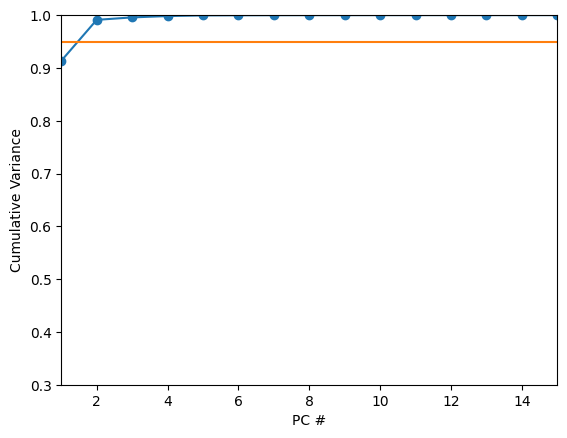

In [6]:
f = plotting.plot_data_pca(data_dict)

The goal of this tutorial is to infer the hiddens (blue), and input to the integrator RNN (umm... also blue).

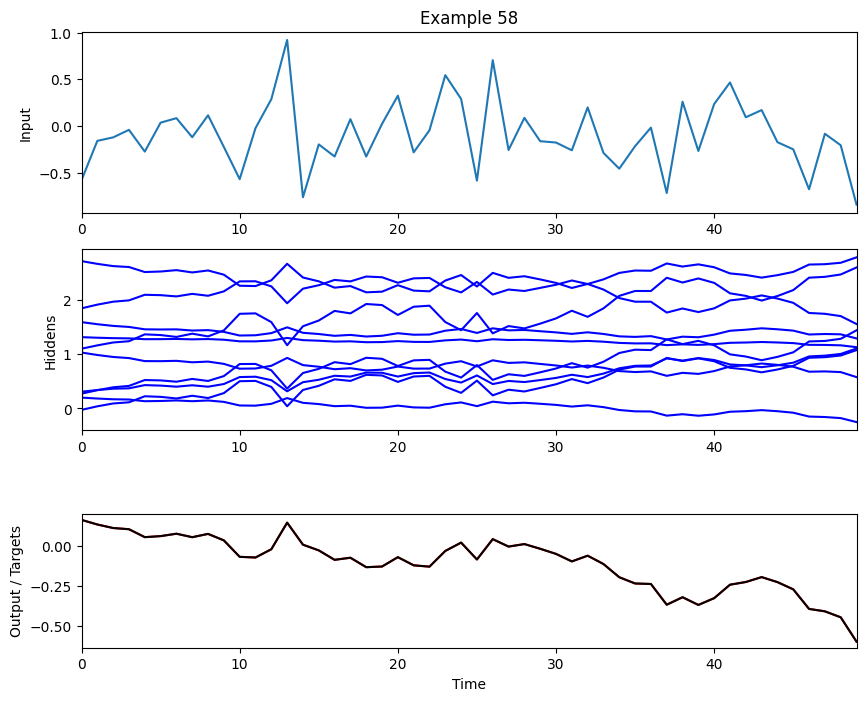

In [7]:
f = plotting.plot_data_example(data_dict['inputs'], 
                               data_dict['hiddens'],
                               data_dict['outputs'], 
                               data_dict['targets'])

### Spikify the synthetic data

The integrator produces continuous hidden activity in the interval $[-1, 1]$. LFADS is designed for binned neural spike counts, so we first map each hidden activation $h_{t,n}$ to a nonnegative rate scale:

$$
r_{t,n} = \frac{h_{t,n} + 1}{2},
\qquad r_{t,n} \in [0,1].
$$

We then draw a spike count for neuron $n$ in time bin $t$:

$$
y_{t,n} \sim \operatorname{Poisson}
\!\left(r_{t,n}\,r_{\max}\,\Delta t\right).
$$

Here, $r_{\max}$ is the maximum firing rate in spikes per second and $\Delta t$ is the bin width in seconds.


In [8]:
data_dt = 1.0/25.0        # define our dt in a physiological range

# If data is normed between 0 and 1, then a 1 yields this many 
# spikes per second. Pushing this downwards makes the problem harder.
max_firing_rate = 80      
train_fraction = 0.9      # Train with 90% of the synthetic data

renormed_fun = lambda x : (x + 1) / 2.0

renormed_data = renormed_fun(data_dict['hiddens'])

# When dimensions are relevant, I use a variable naming scheme like
# name_dim1xdim2x...  so below, here is the synthetic data with 
# 3 dimensions of batch, time and unit, in that order.
data_bxtxn = utils.spikify_data(renormed_data, onp_rng, data_dt,
                                max_firing_rate=max_firing_rate)
nexamples, ntimesteps, data_dim = data_bxtxn.shape

train_data, eval_data = utils.split_data(data_bxtxn,
                                         train_fraction=train_fraction)
eval_data_offset = int(train_fraction * data_bxtxn.shape[0])

In [9]:
eval_data.shape

(26, 50, 40)

#### Plot the statistics of the data.

79.19931640625 spikes/second


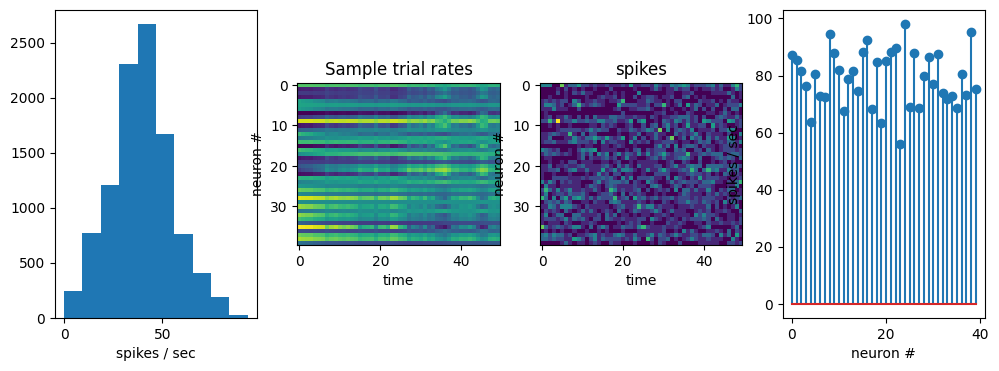

In [10]:
f = plotting.plot_data_stats(data_dict, data_bxtxn, data_dt)

Let's study this single example of a single neuron's true firing rate (red) and the spikified version in the blue stem plot.

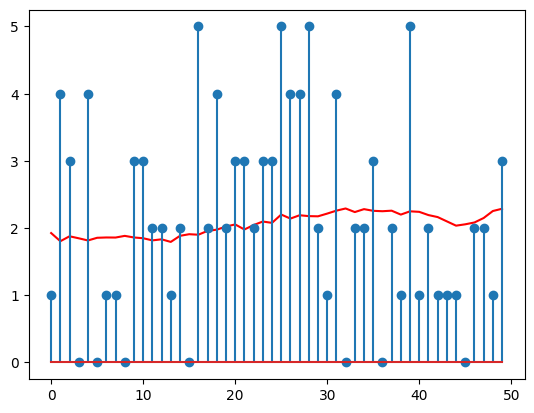

In [11]:
my_example_bidx = eval_data_offset + 0
my_example_hidx = 0
scale = max_firing_rate * data_dt
my_signal = scale*renormed_data[my_example_bidx, :, my_example_hidx]
my_signal_spikified = data_bxtxn[my_example_bidx, :, my_example_hidx]
plt.plot(my_signal, 'r');
plt.stem(my_signal_spikified);

If you were to increase ```max_firing_rate``` to infinity, the stem plot would approach the red line. This plot gives you an idea of how challenging the data set is, at least on single trials. We can think about this a little bit.  If you were to simply filter the spikes, it definitely would not look like the red trace, at this low maximum firing rate. This means that if any technique were to have 

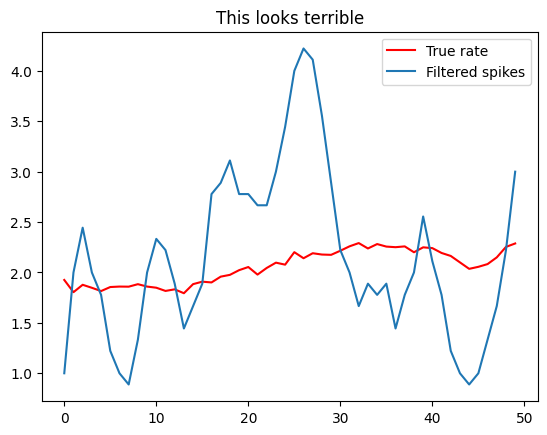

In [12]:
nfilt = 3
my_filtered_spikes = scipy.signal.filtfilt(onp.ones(nfilt)/nfilt, 1, my_signal_spikified)
plt.plot(my_signal, 'r');
plt.plot(my_filtered_spikes);
plt.title("This looks terrible");
plt.legend(('True rate', 'Filtered spikes'));

This would force us to think about ways in which the *population* can be filtered. The first idea is naturally PCA. Perhaps there is a low-d subspace of signal that can be found in the high-variance top PCs. Using the entire trial, it's likely this should do better.

In [13]:
import sklearn

ncomponents = min(20, data_dim)
full_pca = sklearn.decomposition.PCA(ncomponents)
full_pca.fit(onp.reshape(data_bxtxn, [-1, data_dim]))


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",20
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

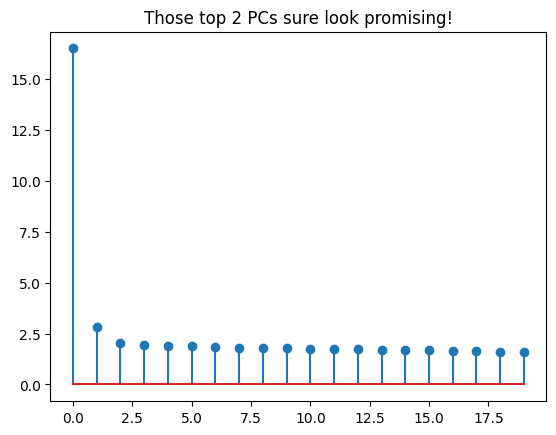

In [14]:
plt.stem(full_pca.explained_variance_)
plt.title('Those top 2 PCs sure look promising!');

In [15]:
ncomponents = 2
pca = sklearn.decomposition.PCA(ncomponents)
pca.fit(onp.reshape(data_bxtxn[0:eval_data_offset,:,:], [-1, data_dim]))
my_example_pca = pca.transform(data_bxtxn[my_example_bidx,:,:])
my_example_ipca = pca.inverse_transform(my_example_pca)

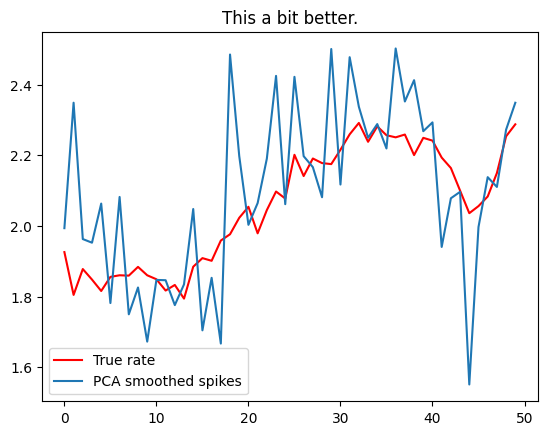

In [16]:
plt.plot(my_signal, 'r')
plt.plot(my_example_ipca[:,my_example_hidx])
plt.legend(('True rate', 'PCA smoothed spikes'))
plt.title('This a bit better.');

So temporal filtering is not great, and spatial filtering helps only a bit.  What to do? The idea LFADS explores is that if you knew the system that generated the data, you would be able to separate signal from noise, the signal being what a system can generate, the noise being the rest.

----------------

## LFADS - Latent Factor Analysis via Dynamical Systems


[Link to paper readcube version of the LFADS Nature Methods 2018 paper](https://rdcu.be/6Wji)



### LFADS architecture with inferred inputs

There are 3 variants of the LFADS architecture in the paper
1. autonomous LFADS model (no inferred inputs), Fig. 1a
2. stitched LFADS model for data recorded in different sessions, Fig. 4a
3. non-autonomous LFADS model (with inferred inputs), Fig. 5a

In this tutorial, we deal with the non-autonomous model, which I believe is conceptually the most interesting, but also the most challenging to understand.  This tutorial (and the current code), does **NOT** handle stitched data.  Stitching data isn't conceptually hard, but it's a pain to code.  The Tensorflow version of the code handles that if you need it. 

Here is the non-autonoumous LFADS model architecture: The full description of this model is given in the paper but briefly, the idea is that the data LFADS will 'denoise' or model data generated from a nonlinear, autonoumous system (we call it the data generator and the data generator in this tutorial is the integrator RNN) that receives an input through time. Based on the spiking observations, LFADS will try to pull apart the data into the dynamical system portion, and the input portion, thus the term *inferred inputs*.  I.e. we are trying to infer what inputs would drive a high-d nonlinear system to generate the data you've recorded. Doing this allows the system to model the dynamics much better for systems that are input-driven. One final detail is that the model assumes that the spikes are poisson generated from an underlying continuous dynamical system. Of course, this is not true for spiking data from biological neural circuits, but the poisson approximation seems to be ok.

So architecture infers a number of quantities of interest: 
1. initial state to the generator (also called initial conditions)
2. inferred inputs to the generator - e.g. the LFADS component to learn the white noise in the integrator RNN example
3. dynamical factors - these are like PCs underlying your data
4. rates - a readout from the factors. The rates are really the most intuitive part, which are analogous to filtering your spiking data. 

![](https://raw.githubusercontent.com/google-research/computation-thru-dynamics/master/images/lfads_architecture_w_inferred_inputs_3.png)


To begin, let's focus on the *autonomous* version of the architecture, which *excludes the controller RNN*.  The data is put through nonlinear, recurrent **encoders**, and this produces an **initial state distribution**, which is a per-trial mean and variance to produce random vectors to encode that trial. The initial state of the generator is a randomly drawn vector from this distribution. The **generator** marches through time and at each time point produces **factors** and **rates**, ultimately producing outputs that learn to reproduce your data at the rate level.  


From the perspective on information flow, the autonomous version of LFADS has a *bottleneck* between your data as inputted into LFADS, and the output, which also tries to learn your data. That bottleneck is the initial state of the generator, a potentially very low-bandwidth bottleneck, as a single vector has to encode a high-d time series. Such a system would be adequate for capturing systems that are (in approximation) autonomous.  For example, motor cortex dynamics during center-out reaches seem extremely well approximated by autonomous dynamics at the sub-second time scale (e.g. Fig 2). However, if you were to perturb the reach by messing with the cursor the animal was using, e.g perturbing cursor location mid-reach, then the motor cortical dynamics of a corrected reach couldn't possibly be autonomous.  In other words, some additional input must have come into the motor cortex and update the system with the information that the cursor had jumped unexpectedly.  This is the experimental setting we setup in Fig. 5.

To compensate for such a scenario, we added a **controller** and **inferred inputs** to the generator portion of LFADS.  In particular, the controller runs in sync with the generator and receives the output of the generator from the last time step (the only "backward" loop in the architecture, aside from using backprop for training with gradient descent).  Thus it knows what the generator output.  During training, the system learns that there are patterns in the data that cannot be created by the generator autonomously, so learns to compensate by emitting information from the data, through the encoders, through the controller to the generator.  We call this information an inferred input. In our experimental setup, this worked well on two examples: messing with the cursor of an animal making a reach and also for inferring oscillations in the local field potential (LFP).

Please note that the inferred input system is extremely powerful as it provides a leak from your input data to the LFADS output on a per-time point basis. As such, one has to make sure that the system  does not pathologically leak all the information from the data trial through LFADS to generate the data trial. LFADS, like all auto-encoders, is at risk of creating a trivial identity function, $x = f(x)$, rather than finding structure in the data. Thus, we utilize many tricks to avoid this (dropout, KL penalties, and even blocking out the information given to the controller from time step t, when decoding time step t.)

### Hyperparameters

In [17]:
# Compact LFADS hyperparameters for a reproducible CPU tutorial.
data_dim = train_data.shape[2]
ntimesteps = train_data.shape[1]
batch_size = 16

enc_dim = 32
con_dim = 32
ii_dim = 1
gen_dim = 32
factors_dim = 12

var_min = 0.001
l2reg = 0.00002


### Hyperparameters for the priors

LFADS is a variational autoencoder. Its information bottleneck is probabilistic: the encoder maps an observed spike sequence $\mathbf{x}_{1:T}$ to a posterior distribution over the generator's initial state $\mathbf{g}_0$:

$$
q_{\phi}(\mathbf{g}_0 \mid \mathbf{x}_{1:T})
=
\mathcal{N}\!\left(
\boldsymbol{\mu}_{\phi}(\mathbf{x}_{1:T}),
\operatorname{diag}\!\left[\boldsymbol{\sigma}_{\phi}^{2}(\mathbf{x}_{1:T})\right]
\right).
$$

The posterior is regularized toward a data-independent Gaussian prior:

$$
p(\mathbf{g}_0)
=
\mathcal{N}\!\left(\mathbf{0},\sigma_{g_0}^{2}\mathbf{I}\right).
$$

The Kullback-Leibler divergence

$$
D_{\mathrm{KL}}\!\left[
q_{\phi}(\mathbf{g}_0 \mid \mathbf{x}_{1:T})
\,\|\,
p(\mathbf{g}_0)
\right]
$$

limits how much trial-specific information can pass through the initial-state code. LFADS applies a second variational bottleneck to the inferred inputs described below.


In [18]:
# Initial state prior parameters
# the mean is set to zero in the code
ic_prior_var = 0.1 # this is $\sigma^2_p$ in above paragraph

### Hyperparameters for inferred inputs

At every time point, the controller produces a Gaussian posterior over the inferred input $\mathbf{u}_t$. LFADS regularizes this sequence using a first-order autoregressive, or AR(1), prior:

$$
\mathbf{u}_t
=
\boldsymbol{\mu}_{u}
+
\phi\left(\mathbf{u}_{t-1}-\boldsymbol{\mu}_{u}\right)
+
\boldsymbol{\epsilon}_t,
\qquad
\boldsymbol{\epsilon}_t
\sim
\mathcal{N}\!\left(\mathbf{0},\sigma_{\epsilon}^{2}\mathbf{I}\right).
$$

The coefficient $\phi$ controls temporal correlation. Using the correlation time constant $\tau$ and bin width $\Delta t$, it can be written as

$$
\phi = \exp\!\left(-\frac{\Delta t}{\tau}\right).
$$

The mean is fixed to $\boldsymbol{\mu}_{u}=\mathbf{0}$ in this tutorial. One independent AR(1) prior is used for each inferred-input dimension. The corresponding KL term discourages the controller from copying the observations directly into the generator while still allowing it to explain input-driven dynamics.


In [19]:
# Inferred input autoregressive prior parameters
# Again, these hyper parameters are set "in the ballpark" but otherwise
# pretty randomly.
ar_mean = 0.0                 # process mean
ar_autocorrelation_tau = 1.0  # seconds, how correlated each time point is, related to $\phi$ above.
ar_noise_variance = 0.1       # noise variance

In [20]:
lfads_hps = utils.HParams({
    "data_dim": data_dim,
    "ntimesteps": ntimesteps,
    "enc_dim": enc_dim,
    "con_dim": con_dim,
    "var_min": var_min,
    "ic_prior_var": ic_prior_var,
    "ar_mean": ar_mean,
    "ar_autocorrelation_tau": ar_autocorrelation_tau,
    "ar_noise_variance": ar_noise_variance,
    "ii_dim": ii_dim,
    "gen_dim": gen_dim,
    "factors_dim": factors_dim,
    "l2reg": l2reg,
    "batch_size": batch_size,
})


#### LFADS Optimization hyperparameters

In [21]:
# Increase num_batches for a final experiment; these defaults finish on CPU.
num_batches = 50
print_every = 10

step_size = 0.01
decay_factor = 0.999
decay_steps = 1

keep_rate = 0.98
max_grad_norm = 10.0


### Warming up the KL penalties

For observations $\mathbf{x}$ and latent variables $\mathbf{z}$, the evidence lower bound is

$$
\mathcal{L}_{\mathrm{ELBO}}(\theta,\phi;\mathbf{x})
=
\mathbb{E}_{q_{\phi}(\mathbf{z}\mid\mathbf{x})}
\!\left[
\log p_{\theta}(\mathbf{x}\mid\mathbf{z})
\right]
-
D_{\mathrm{KL}}\!\left[
q_{\phi}(\mathbf{z}\mid\mathbf{x})
\,\|\,
p(\mathbf{z})
\right].
$$

LFADS uses two latent codes: the generator initial state $\mathbf{g}_0$ and the inferred-input sequence $\mathbf{u}_{1:T}$. The code minimizes the negative, KL-weighted ELBO:

$$
\begin{aligned}
\mathcal{J}_{\beta}
={}&
-\mathbb{E}_{q_{\phi}}
\!\left[
\log p_{\theta}(\mathbf{x}_{1:T}\mid\mathbf{g}_0,\mathbf{u}_{1:T})
\right] \\
&+\beta\,
D_{\mathrm{KL}}\!\left[
q_{\phi}(\mathbf{g}_0\mid\mathbf{x}_{1:T})
\,\|\,
p(\mathbf{g}_0)
\right] \\
&+\beta\,
D_{\mathrm{KL}}\!\left[
q_{\phi}(\mathbf{u}_{1:T}\mid\mathbf{x}_{1:T})
\,\|\,
p(\mathbf{u}_{1:T})
\right]
+\lambda\lVert\theta\rVert_2^2.
\end{aligned}
$$

Optimizing the KL terms too strongly at the start can cause posterior collapse: the approximate posterior approaches the prior before the model learns to reconstruct the observations. KL warm-up addresses this by increasing $\beta$ gradually from a small value to its final value during training.


In [22]:
kl_warmup_start = 5.0
kl_warmup_end = 30.0
kl_min = 0.01


The final KL weight is controlled by `kl_max`. Setting $\beta=1$ recovers the standard ELBO; values above or below one change the balance between reconstruction fidelity and latent regularization.

Related references:

- [beta-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework](https://openreview.net/pdf?id=Sy2fzU9gl)
- [Fixing a Broken ELBO](https://arxiv.org/pdf/1711.00464.pdf)


In [23]:
kl_max = 1.0

In [24]:
lfads_opt_hps = utils.HParams({
    "num_batches": num_batches,
    "step_size": step_size,
    "decay_steps": decay_steps,
    "decay_factor": decay_factor,
    "kl_min": kl_min,
    "kl_max": kl_max,
    "kl_warmup_start": kl_warmup_start,
    "kl_warmup_end": kl_warmup_end,
    "keep_rate": keep_rate,
    "max_grad_norm": max_grad_norm,
    "print_every": print_every,
    "adam_b1": 0.9,
    "adam_b2": 0.999,
    "adam_eps": 1e-1,
})

assert num_batches >= print_every and num_batches % print_every == 0


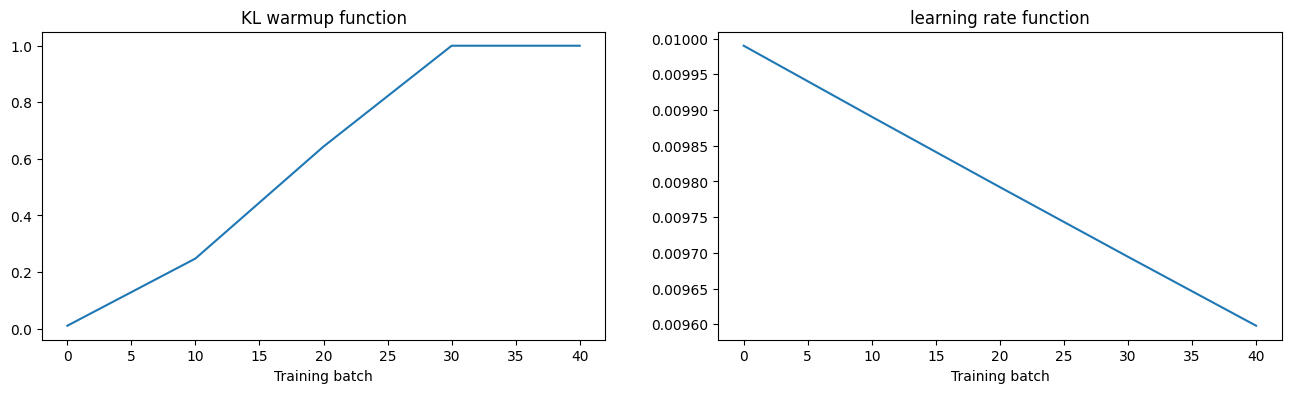

In [25]:
# Plot the warmup function and the learning rate decay function.
plt.figure(figsize=(16,4))
plt.subplot(121)
x = onp.arange(0, num_batches, print_every)
kl_warmup_fun = get_kl_warmup_fun(lfads_opt_hps)
plt.plot(x, [kl_warmup_fun(i) for i in onp.arange(1,lfads_opt_hps['num_batches'], print_every)]);
plt.title('KL warmup function')
plt.xlabel('Training batch');

plt.subplot(122)
decay_fun = optimizers.exponential_decay(lfads_opt_hps['step_size'],                                                             
                                         lfads_opt_hps['decay_steps'],                                                           
                                         lfads_opt_hps['decay_factor'])                                                          
plt.plot(x, [decay_fun(i) for i in range(1, lfads_opt_hps['num_batches'], print_every)]);
plt.title('learning rate function')
plt.xlabel('Training batch');                                                                                     

### Train the LFADS model

Note that JAX uses its own setup to handle randomness and seeding the pseudo-random number generators.  You can read about it [here](https://github.com/google/jax/blob/master/README.md#random-numbers-are-different). If you want to modify the LFADS tutorial you *NEED* to understand this. Otherwise, not so big a deal if you are just messing around with LFADS hyperparameters or applying the tutorial to new data.

In [26]:
# Initialize parameters for LFADS
key = random.PRNGKey(onp.random.randint(0, utils.MAX_SEED_INT))
init_params = lfads.lfads_params(key, lfads_hps)

The first optimization block includes JAX compilation and is therefore slower than subsequent blocks. The default configuration uses 50 batches so the complete notebook remains practical on the CPU backend reported above. Increase `num_batches` only after verifying the full workflow.


In [27]:
key = random.PRNGKey(onp.random.randint(0, utils.MAX_SEED_INT))
trained_params, opt_details = \
    optimize_lfads(key, init_params, lfads_hps, lfads_opt_hps,
                   train_data, eval_data)

Batches 1-10 in 19.59 sec, Step size: 0.00990
    Training losses 1792 = NLL 1790 + KL IC 147,1 + KL II 79,1 + L2 0.02
        Eval losses 1710 = NLL 1707 + KL IC 150,1 + KL II 84,1 + L2 0.02
Batches 11-20 in 0.01 sec, Step size: 0.00980


    Training losses 1679 = NLL 1664 + KL IC 48,10 + KL II 20,4 + L2 0.02
        Eval losses 1522 = NLL 1506 + KL IC 49,10 + KL II 24,5 + L2 0.02
Batches 21-30 in 0.00 sec, Step size: 0.00970
    Training losses 1577 = NLL 1551 + KL IC 18,11 + KL II 25,15 + L2 0.02
        Eval losses 1491 = NLL 1468 + KL IC 17,10 + KL II 22,13 + L2 0.02
Batches 31-40 in 0.00 sec, Step size: 0.00961


    Training losses 1532 = NLL 1506 + KL IC 9,9 + KL II 17,17 + L2 0.02
        Eval losses 1450 = NLL 1422 + KL IC 10,10 + KL II 18,18 + L2 0.02
Batches 41-50 in 0.00 sec, Step size: 0.00951


    Training losses 1450 = NLL 1421 + KL IC 9,9 + KL II 19,19 + L2 0.02
        Eval losses 1359 = NLL 1326 + KL IC 10,10 + KL II 22,22 + L2 0.02


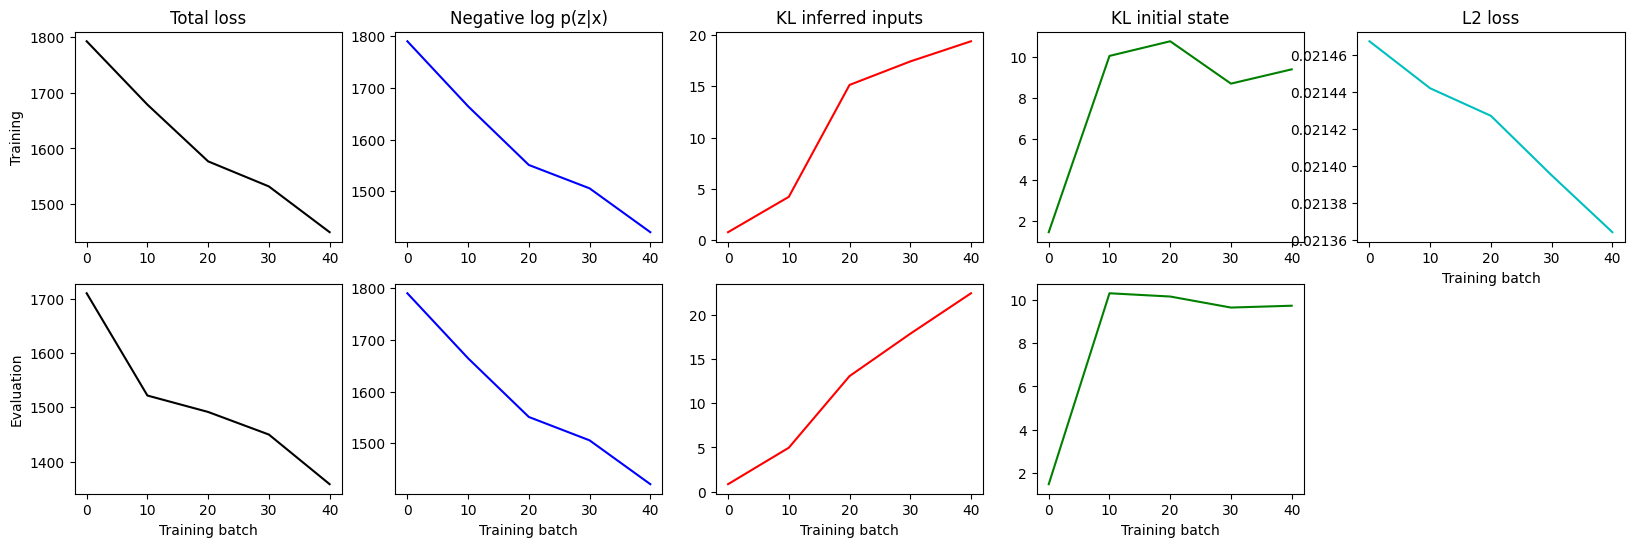

In [28]:
# Plot the training details
x = onp.arange(0, num_batches, print_every)
plt.figure(figsize=(20,6))
plt.subplot(251)
plt.plot(x, opt_details['tlosses']['total'], 'k')
plt.ylabel('Training')
plt.title('Total loss')
plt.subplot(252)
plt.plot(x, opt_details['tlosses']['nlog_p_xgz'], 'b')
plt.title('Negative log p(z|x)')
plt.subplot(253)
plt.plot(x, opt_details['tlosses']['kl_ii'], 'r')
plt.title('KL inferred inputs')
plt.subplot(254)
plt.plot(x, opt_details['tlosses']['kl_g0'], 'g')
plt.title('KL initial state')
plt.subplot(255)
plt.plot(x, opt_details['tlosses']['l2'], 'c')
plt.xlabel('Training batch')
plt.title('L2 loss')
plt.subplot(256)
plt.plot(x, opt_details['elosses']['total'], 'k')
plt.xlabel('Training batch')
plt.ylabel('Evaluation')
plt.subplot(257)
plt.plot(x, opt_details['tlosses']['nlog_p_xgz'], 'b')
plt.xlabel('Training batch')
plt.subplot(258)
plt.plot(x, opt_details['elosses']['kl_ii'], 'r')
plt.xlabel('Training batch')
plt.subplot(259)
plt.plot(x, opt_details['elosses']['kl_g0'], 'g')
plt.xlabel('Training batch');

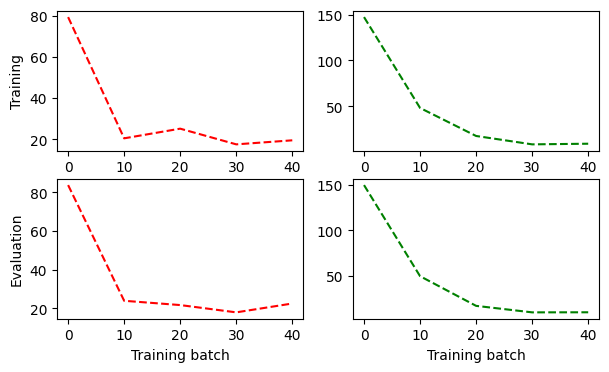

In [29]:
# See the effect of the KL warmup, which is shown 
# by the KL penalities without the warmup scaling. 
plt.figure(figsize=(7,4))
plt.subplot(221)
plt.plot(x, opt_details['tlosses']['kl_ii_prescale'], 'r--')
plt.ylabel('Training')
plt.subplot(222)
plt.plot(x, opt_details['tlosses']['kl_g0_prescale'], 'g--')
plt.subplot(223)
plt.plot(x, opt_details['elosses']['kl_ii_prescale'], 'r--')
plt.ylabel('Evaluation')
plt.xlabel('Training batch')
plt.subplot(224)
plt.plot(x, opt_details['elosses']['kl_g0_prescale'], 'g--')
plt.xlabel('Training batch');

### Save the LFADS model parameters

In [30]:
fname_uniquifier = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
network_fname = f"trained_params_{rnn_type}_{task_type}_{fname_uniquifier}.npz"
network_path = output_dir / network_fname

print("Saving parameters:", network_path)
onp.savez(network_path, trained_params)


Saving parameters: D:\Variational-Neural-Inference\VAE-Tutorial\outputs\lfads_jax\output\trained_params_lfads_integrator_2026-07-15_15-07-11.npz


In [31]:
# After training, you can load these up, after locating the save file.
if False:
    loaded_params = onp.load(network_path, allow_pickle=True)
    trained_params = loaded_params['arr_0'].item()

### LFADS Visualization
To plot the results of LFADS, namely the inferred quantities such as the inferred inputs, factors, or rates, we have to do a sample-and-average operation.  Remember, the latent variables for LFADS are the initial state and the inferred inputs, and they are per-trial *stochastic* codes, even for a *single trial*.  To get good inference for a given trial, we sample a large number of times from these per-trial stochastic latent variables, run the generator forward, and then average all the quantities of interest over the samples. 

If LFADS were linear a linear model, it would be equivalent to do the *much more efficient decode* of the posterior means, that is, just take the mean of the initial state distribution and the mean of the inferred input distribution, and then run the decoder one time. (This, btw, is a great exercise to the tutorial reader: implement posterior-mean decoding in this tutorial.)

Here we use batching and take the 'posterior average' using batch number of samples from the latent variable distributions.

So the main result of this tutorial, the moment you've been waiting for, is the comparison between the true rates of the integrator RNN, and the inferred rates by LFADS, and the true input to the integrator RNN and the inferred inputs given by LFADS.  You can see how well we did by generating lots of trials here.

bidx:  230


C:\Users\10993\.conda\envs\Deeplearning\Lib\site-packages\scipy\stats\_stats_py.py:10933: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
C:\Users\10993\.conda\envs\Deeplearning\Lib\site-packages\scipy\stats\_stats_py.py:10936: RuntimeWarning: invalid value encountered in sqrt
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


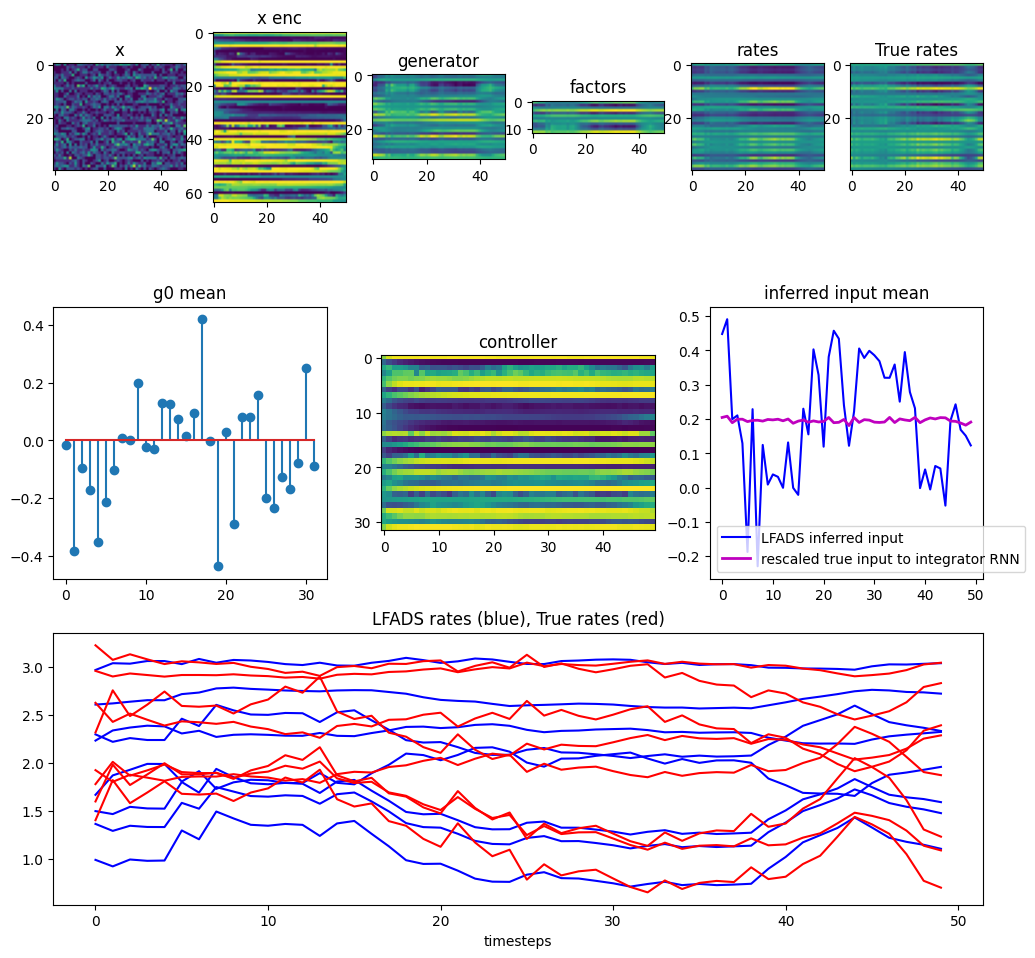

In [32]:
# Plot a bunch of examples of eval trials run through LFADS.
reload(plotting)
#reload(lfads)

def plot_rescale_fun(a): 
    fac = max_firing_rate * data_dt
    return renormed_fun(a) * fac


bidx = my_example_bidx - eval_data_offset
bidx = 0

nexamples_to_save = 1
for eidx in range(nexamples_to_save):
    fkey = random.fold_in(key, eidx)
    psa_example = eval_data[bidx,:,:].astype(np.float32)
    psa_dict = lfads.posterior_sample_and_average_jit(trained_params, lfads_hps, fkey, psa_example)

    # The inferred input and true input are rescaled and shifted via 
    # linear regression to match, as there is an identifiability issue. there.
    plotting.plot_lfads(psa_example, psa_dict,
                        data_dict, eval_data_offset+bidx, plot_rescale_fun)

And coming back to our example signal, how well does LFADS do on it, compared to the other *much easier to implement* methods? A noticeable improvement on inferring the underlying rate.

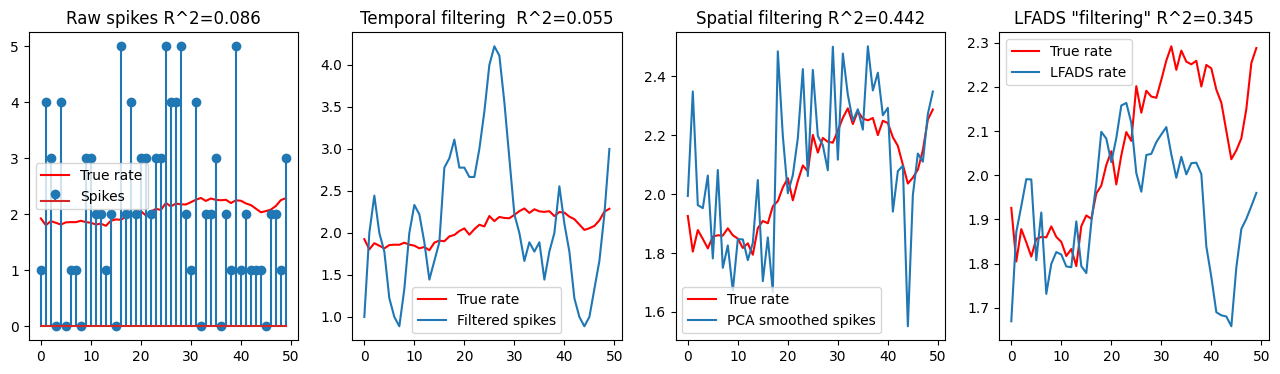

In [33]:
plt.figure(figsize=(16,4))

plt.subplot(141)
plt.plot(my_signal, 'r');
plt.stem(my_signal_spikified);
_, _, r2_spike, _, _ = scipy.stats.linregress(my_signal_spikified, my_signal)
plt.title('Raw spikes R^2=%.3f' % (r2_spike))
plt.legend(('True rate', 'Spikes'));


plt.subplot(142)
plt.plot(my_signal, 'r');
plt.plot(my_filtered_spikes);
_, _, c_tfilt, _, _ = scipy.stats.linregress(my_filtered_spikes, my_signal)
plt.title("Temporal filtering  R^2=%.3f" % (c_tfilt**2));
plt.legend(('True rate', 'Filtered spikes'));

plt.subplot(143)
plt.plot(my_signal, 'r')
plt.plot(my_example_ipca[:,my_example_hidx])
_, _, c_sfilt, _, _ = scipy.stats.linregress(my_example_ipca[:,my_example_hidx], my_signal)
plt.legend(('True rate', 'PCA smoothed spikes'))
plt.title('Spatial filtering R^2=%.3f' % (c_sfilt**2));

plt.subplot(144)
plt.plot(my_signal, 'r')
my_lfads_rate = onp.exp(psa_dict['lograte_t'][:,my_example_hidx])
plt.plot(my_lfads_rate)
_, _, r2_lfads, _, _ = scipy.stats.linregress(my_lfads_rate, my_signal)
plt.legend(('True rate', 'LFADS rate'))
plt.title('LFADS "filtering" R^2=%.3f' % (r2_lfads));

That single example can't tell the whole story so let us look at the average. LFADS is much better than spatial averaging across a large set of trials.

Take an average over all the hidden units in 100 evaluation trials.

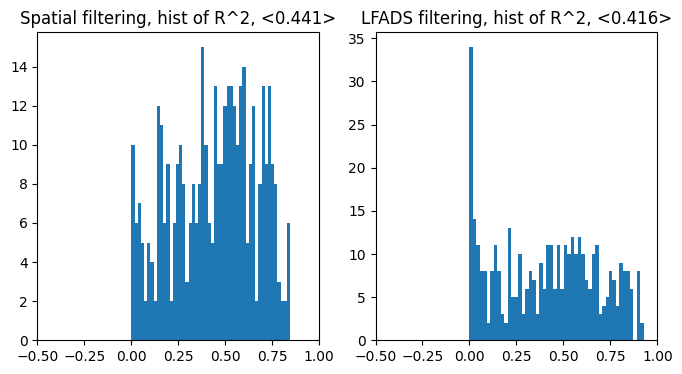

In [34]:
nexamples = min(10, eval_data.shape[0])
r2_sfilts = onp.zeros(nexamples*data_dim)
r2_lfadss = onp.zeros(nexamples*data_dim)
eidx = 0
for bidx in range(nexamples):
    ebidx = eval_data_offset + bidx
    
    # Get the LFADS decode for this trial.
    fkey = random.fold_in(key, bidx)
    psa_example = eval_data[bidx,:,:].astype(np.float32)
    psa_dict = lfads.posterior_sample_and_average_jit(trained_params, lfads_hps, fkey, psa_example)
    
    # Get the spatially smoothed trial.
    trial_rates = scale*renormed_data[ebidx, :, :]
    trial_spikes = data_bxtxn[ebidx, :, :]
    spikes_pca = pca.transform(trial_spikes)
    spikes_ipca = pca.inverse_transform(spikes_pca)
    
    for hidx in range(data_dim):
        sig = trial_rates[:, hidx]
        ipca_rate = spikes_ipca[:,hidx]
        lfads_rate = onp.exp(psa_dict['lograte_t'][:,hidx])
        _, _, cc_sfilt, _, _ = scipy.stats.linregress(ipca_rate, sig)
        _, _, cc_lfads, _, _ = scipy.stats.linregress(lfads_rate, sig)

        r2_sfilts[eidx] = cc_sfilt**2
        r2_lfadss[eidx] = cc_lfads**2
        eidx += 1
    
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.hist(r2_sfilts, 50)
plt.title('Spatial filtering, hist of R^2, <%.3f>' % (onp.mean(r2_sfilts)))
plt.xlim([-.5, 1.0])

plt.subplot(122)
plt.hist(r2_lfadss, 50);
plt.title('LFADS filtering, hist of R^2, <%.3f>' % (onp.mean(r2_lfadss)));
plt.xlim([-.5, 1.0]);

### Compare inferred and true inputs

The inferred input is identifiable only up to a linear transformation. We therefore fit a linear regression that aligns the one-dimensional inferred input with the known integrator input, then report the coefficient of determination $R^2$.


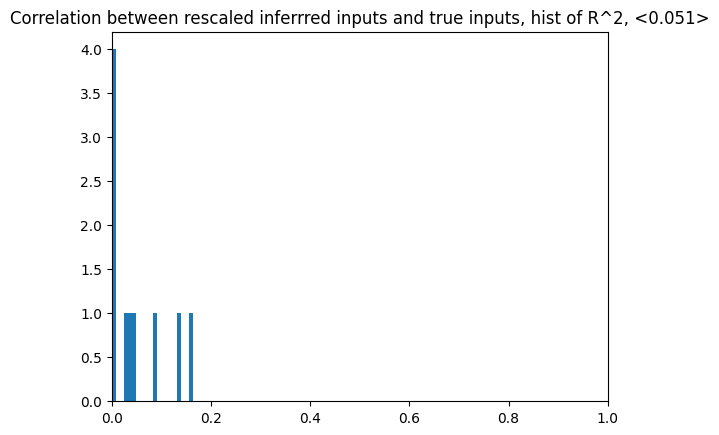

In [35]:
r2_iis = []
nexamples = min(10, eval_data.shape[0])
for bidx in range(nexamples):
    ebidx = eval_data_offset + bidx
    
    # Get the LFADS decode for this trial.
    psa_example = eval_data[bidx,:,:].astype(np.float32)
    fkey = random.fold_in(key, bidx)
    psa_dict = lfads.posterior_sample_and_average_jit(trained_params, lfads_hps, fkey, psa_example)
    
    # Get the true input and inferred input
    true_input = onp.squeeze(data_dict['inputs'][ebidx])
    inferred_input = onp.squeeze(psa_dict['ii_t'])
    slope, intercept, _, _, _ = scipy.stats.linregress(inferred_input, true_input)
    _, _, cc_ii, _, _ = scipy.stats.linregress(slope * inferred_input + intercept, true_input)
    
    r2_iis.append(cc_ii**2)
    
r2_iis = onp.array(r2_iis)

plt.hist(r2_iis, 20)
plt.title('Correlation between rescaled inferrred inputs and true inputs, hist of R^2, <%.3f>' % (onp.mean(r2_iis)))
plt.xlim([0.0, 1.0]);

### Compare the inferred initial state for the LFADS generator to the actual initial state of the integrator RNN.

To finish, we can examine the relationship between the initial condition (h0) of the integrator RNN and the inferred initial condition of the LFADS generator.
The color we use is the readout of the integrator RNN's initial state, so basically, the state of the line attractor before further information is presented.  In the integrator RNN example, we made sure to seed these initial states with various values along the line attractor, so we expect a line of coloration.

In [36]:
ntrials = min(25, eval_data.shape[0])
true_h0s = onp.zeros([ntrials, data_dim])
ic_means = onp.zeros([ntrials, gen_dim])
colors = onp.zeros(ntrials)
for bidx in range(ntrials):
    ebidx = eval_data_offset + bidx
    
    # Get the LFADS decode for this trial.
    psa_example = eval_data[bidx,:,:].astype(np.float32)
    fkey = random.fold_in(key, bidx)
    #psa_dict = lfads.posterior_sample_and_average_jit(trained_params, lfads_hps, fkey, psa_example)
    lfads_results = lfads.lfads_jit(trained_params, lfads_hps, fkey, psa_example, 1.0)
    # Get the true initial condition (and the readout of the true h0 for color)
    # Get the inferred input from LFADS
    true_h0s[bidx,:] = data_dict['h0s'][ebidx]
    colors[bidx] = data_dict['outputs'][ebidx, 0, 0]
    ic_means[bidx,:] = lfads_results['ic_mean']


Text(0.5, 1.0, 'TSNE visualziation of LFADS inferred intial generator state.')

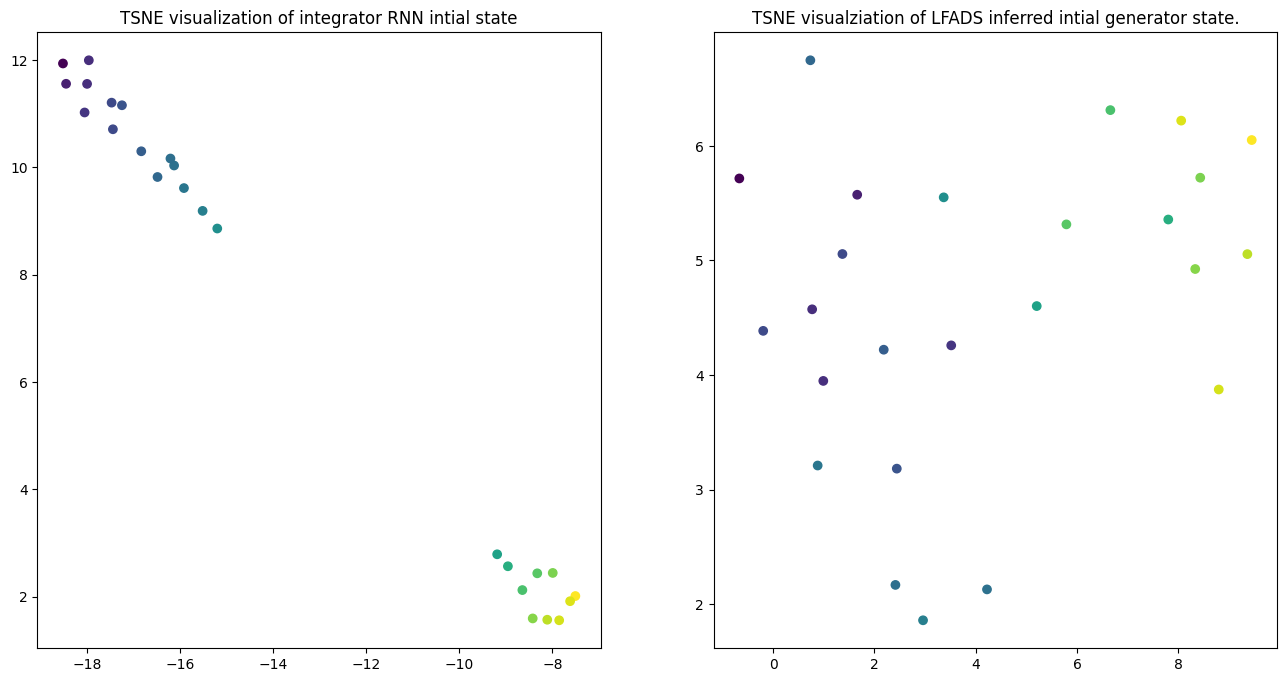

In [37]:
from sklearn.manifold import TSNE
plt.figure(figsize=(16,8))
plt.subplot(121)
h0s_embedded = TSNE(n_components=2, perplexity=min(10, ntrials - 1), random_state=0).fit_transform(true_h0s)
plt.scatter(h0s_embedded[:,0], h0s_embedded[:,1], c=colors)
plt.title('TSNE visualization of integrator RNN intial state')
plt.subplot(122)
ic_means_embedded = TSNE(n_components=2, perplexity=min(10, ntrials - 1), random_state=0).fit_transform(ic_means)
plt.scatter(ic_means_embedded[:,0], ic_means_embedded[:,1], c=colors);
plt.title('TSNE visualziation of LFADS inferred intial generator state.')